In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

print("Done.")

Done.


[nltk_data] Downloading package stopwords to
[nltk_data]     /home/2ae3a15c-0ba3-4f9a-887f-
[nltk_data]     4bf317483540/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /home/2ae3a15c-0ba3-4f9a-887f-
[nltk_data]     4bf317483540/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/2ae3a15c-0ba3-4f9a-887f-
[nltk_data]     4bf317483540/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [2]:
!pip install vaderSentiment textblob nltk scikit-learn pandas matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

print("Done.")

Done.


[nltk_data] Downloading package stopwords to
[nltk_data]     /home/2ae3a15c-0ba3-4f9a-887f-
[nltk_data]     4bf317483540/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /home/2ae3a15c-0ba3-4f9a-887f-
[nltk_data]     4bf317483540/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/2ae3a15c-0ba3-4f9a-887f-
[nltk_data]     4bf317483540/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [4]:
df = pd.read_csv('Reviews.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (568454, 10)


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [5]:
df = df.sample(n=10000, random_state=42).reset_index(drop=True)
print(f"Sampled shape: {df.shape}")
print(df.isnull().sum())

Sampled shape: (10000, 10)
Id                        0
ProductId                 0
UserId                    0
ProfileName               0
HelpfulnessNumerator      0
HelpfulnessDenominator    0
Score                     0
Time                      0
Summary                   1
Text                      0
dtype: int64


In [6]:
df = df[['Score', 'Summary', 'Text']].dropna()
print(f"Shape after dropna: {df.shape}")

Shape after dropna: (9999, 3)


In [7]:
def map_sentiment(score):
    if score <= 2:
        return 'negative'
    elif score == 3:
        return 'neutral'
    else:
        return 'positive'

df['Sentiment'] = df['Score'].apply(map_sentiment)
print(df['Sentiment'].value_counts())

Sentiment
positive    7852
negative    1397
neutral      750
Name: count, dtype: int64


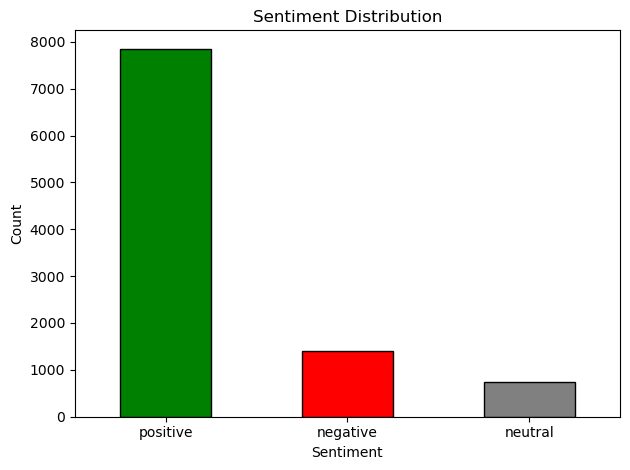

In [8]:
df['Sentiment'].value_counts().plot(kind='bar', color=['green', 'red', 'gray'], edgecolor='black')
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [9]:
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'<.*?>', '', text)           # remove HTML tags
    text = re.sub(r'[^a-zA-Z\s]', '', text)     # remove non-alphabet
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = word_tokenize(text)
    tokens = [stemmer.stem(w) for w in tokens if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)

print("Cleaning text...")
df['Cleaned_Text'] = df['Text'].apply(clean_text)
print("Done!")

Cleaning text...
Done!


In [10]:
print("Original:", df['Text'].iloc[0][:300])
print()
print("Cleaned: ", df['Cleaned_Text'].iloc[0][:300])

Original: Having tried a couple of other brands of gluten-free sandwich cookies, these are the best of the bunch.  They're crunchy and true to the texture of the other "real" cookies that aren't gluten-free.  Some might think that the filling makes them a bit too sweet, but for me that just means I've satisfi

Cleaned:  tri coupl brand glutenfre sandwich cooki best bunch theyr crunchi true textur real cooki arent glutenfre might think fill make bit sweet mean ive satisfi sweet tooth sooner chocol version glutino good true chocolatey tast someth isnt glutenfre brand


In [11]:
df.to_csv('Reviews_cleaned.csv', index=False)
print("Saved as Reviews_cleaned.csv")

Saved as Reviews_cleaned.csv


In [12]:
df_ml = df[df['Sentiment'] != 'neutral'].copy()
df_ml['Label'] = df_ml['Sentiment'].map({'positive': 1, 'negative': 0})

X = df_ml['Cleaned_Text']
y = df_ml['Label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")

Train: 7399 | Test: 1850


In [13]:
bow_vectorizer = CountVectorizer(max_features=5000)
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow  = bow_vectorizer.transform(X_test)
print(f"BoW shape: {X_train_bow.shape}")

BoW shape: (7399, 5000)


In [14]:
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf  = tfidf_vectorizer.transform(X_test)
print(f"TF-IDF shape: {X_train_tfidf.shape}")

TF-IDF shape: (7399, 5000)


In [15]:
def textblob_predict(text):
    polarity = TextBlob(str(text)).sentiment.polarity
    if polarity > 0:
        return 'positive'
    elif polarity < 0:
        return 'negative'
    else:
        return 'neutral'

print("Running TextBlob...")
df['TextBlob_Sentiment'] = df['Text'].apply(textblob_predict)
print("Done!")

Running TextBlob...
Done!


In [16]:
df_eval    = df[df['Sentiment'] != 'neutral'].copy()
df_eval_tb = df_eval[df_eval['TextBlob_Sentiment'] != 'neutral'].copy()

tb_acc = accuracy_score(df_eval_tb['Sentiment'], df_eval_tb['TextBlob_Sentiment'])
print(f"TextBlob Accuracy: {tb_acc:.4f}")
print(classification_report(df_eval_tb['Sentiment'], df_eval_tb['TextBlob_Sentiment']))

TextBlob Accuracy: 0.8687
              precision    recall  f1-score   support

    negative       0.59      0.39      0.47      1363
    positive       0.90      0.95      0.93      7771

    accuracy                           0.87      9134
   macro avg       0.74      0.67      0.70      9134
weighted avg       0.85      0.87      0.86      9134



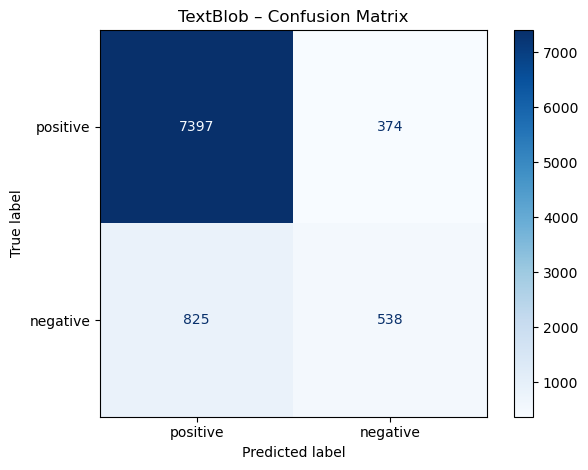

In [17]:
cm_tb = confusion_matrix(df_eval_tb['Sentiment'], df_eval_tb['TextBlob_Sentiment'], labels=['positive','negative'])
ConfusionMatrixDisplay(cm_tb, display_labels=['positive','negative']).plot(cmap='Blues')
plt.title('TextBlob – Confusion Matrix')
plt.tight_layout()
plt.show()

In [18]:
vader = SentimentIntensityAnalyzer()

def vader_predict(text):
    score = vader.polarity_scores(str(text))['compound']
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

print("Running VADER...")
df['VADER_Sentiment'] = df['Text'].apply(vader_predict)
print("Done!")

Running VADER...
Done!


In [19]:
df_eval_vd = df_eval[df_eval['VADER_Sentiment'] != 'neutral'].copy()

vd_acc = accuracy_score(df_eval_vd['Sentiment'], df_eval_vd['VADER_Sentiment'])
print(f"VADER Accuracy: {vd_acc:.4f}")
print(classification_report(df_eval_vd['Sentiment'], df_eval_vd['VADER_Sentiment']))

KeyError: 'VADER_Sentiment'

In [20]:
df_eval_vd = df_eval[df_eval['VADER_Sentiment'] != 'neutral'].copy()

vd_acc = accuracy_score(df_eval_vd['Sentiment'], df_eval_vd['VADER_Sentiment'])
print(f"VADER Accuracy: {vd_acc:.4f}")
print(classification_report(df_eval_vd['Sentiment'], df_eval_vd['VADER_Sentiment']))


KeyError: 'VADER_Sentiment'

In [21]:
df_eval_vd = df[df['Sentiment'] != 'neutral'].copy()
df_eval_vd = df_eval_vd[df_eval_vd['VADER_Sentiment'] != 'neutral'].copy()

vd_acc = accuracy_score(df_eval_vd['Sentiment'], df_eval_vd['VADER_Sentiment'])
print(f"VADER Accuracy: {vd_acc:.4f}")
print(classification_report(df_eval_vd['Sentiment'], df_eval_vd['VADER_Sentiment']))

VADER Accuracy: 0.8893
              precision    recall  f1-score   support

    negative       0.70      0.43      0.53      1325
    positive       0.91      0.97      0.94      7752

    accuracy                           0.89      9077
   macro avg       0.80      0.70      0.73      9077
weighted avg       0.88      0.89      0.88      9077



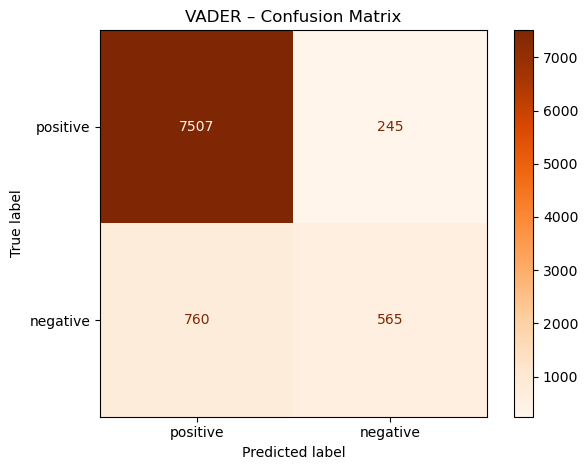

In [22]:
cm_vd = confusion_matrix(df_eval_vd['Sentiment'], df_eval_vd['VADER_Sentiment'], labels=['positive','negative'])
ConfusionMatrixDisplay(cm_vd, display_labels=['positive','negative']).plot(cmap='Oranges')
plt.title('VADER – Confusion Matrix')
plt.tight_layout()
plt.show()

In [23]:
label_names = ['negative', 'positive']

nb_bow = MultinomialNB()
nb_bow.fit(X_train_bow, y_train)
nb_bow_pred = nb_bow.predict(X_test_bow)
nb_bow_acc  = accuracy_score(y_test, nb_bow_pred)

print(f"Naive Bayes + BoW Accuracy: {nb_bow_acc:.4f}")
print(classification_report(y_test, nb_bow_pred, target_names=label_names))

Naive Bayes + BoW Accuracy: 0.9054
              precision    recall  f1-score   support

    negative       0.72      0.60      0.66       279
    positive       0.93      0.96      0.95      1571

    accuracy                           0.91      1850
   macro avg       0.83      0.78      0.80      1850
weighted avg       0.90      0.91      0.90      1850



In [24]:
nb_tfidf = MultinomialNB()
nb_tfidf.fit(X_train_tfidf, y_train)
nb_tfidf_pred = nb_tfidf.predict(X_test_tfidf)
nb_tfidf_acc  = accuracy_score(y_test, nb_tfidf_pred)

print(f"Naive Bayes + TF-IDF Accuracy: {nb_tfidf_acc:.4f}")
print(classification_report(y_test, nb_tfidf_pred, target_names=label_names))

Naive Bayes + TF-IDF Accuracy: 0.8524
              precision    recall  f1-score   support

    negative       0.88      0.03      0.05       279
    positive       0.85      1.00      0.92      1571

    accuracy                           0.85      1850
   macro avg       0.86      0.51      0.48      1850
weighted avg       0.86      0.85      0.79      1850



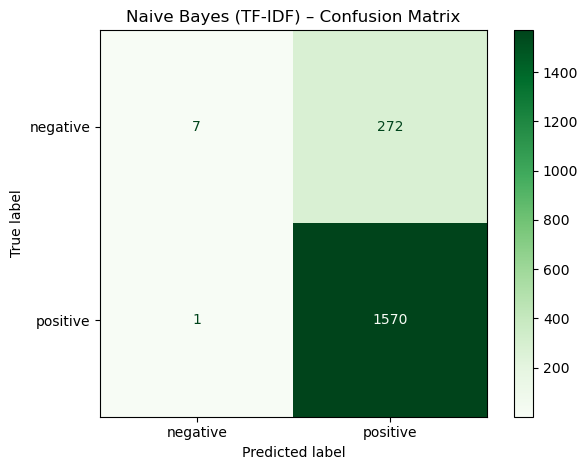

In [25]:
cm_nb = confusion_matrix(y_test, nb_tfidf_pred)
ConfusionMatrixDisplay(cm_nb, display_labels=label_names).plot(cmap='Greens')
plt.title('Naive Bayes (TF-IDF) – Confusion Matrix')
plt.tight_layout()
plt.show()

In [26]:
svm_bow = LinearSVC(random_state=42, max_iter=1000)
svm_bow.fit(X_train_bow, y_train)
svm_bow_pred = svm_bow.predict(X_test_bow)
svm_bow_acc  = accuracy_score(y_test, svm_bow_pred)

print(f"SVM + BoW Accuracy: {svm_bow_acc:.4f}")
print(classification_report(y_test, svm_bow_pred, target_names=label_names))

SVM + BoW Accuracy: 0.8778
              precision    recall  f1-score   support

    negative       0.59      0.62      0.60       279
    positive       0.93      0.92      0.93      1571

    accuracy                           0.88      1850
   macro avg       0.76      0.77      0.77      1850
weighted avg       0.88      0.88      0.88      1850



In [27]:
svm_tfidf = LinearSVC(random_state=42, max_iter=1000)
svm_tfidf.fit(X_train_tfidf, y_train)
svm_tfidf_pred = svm_tfidf.predict(X_test_tfidf)
svm_tfidf_acc  = accuracy_score(y_test, svm_tfidf_pred)

print(f"SVM + TF-IDF Accuracy: {svm_tfidf_acc:.4f}")
print(classification_report(y_test, svm_tfidf_pred, target_names=label_names))

SVM + TF-IDF Accuracy: 0.9049
              precision    recall  f1-score   support

    negative       0.75      0.56      0.64       279
    positive       0.92      0.97      0.95      1571

    accuracy                           0.90      1850
   macro avg       0.84      0.76      0.79      1850
weighted avg       0.90      0.90      0.90      1850



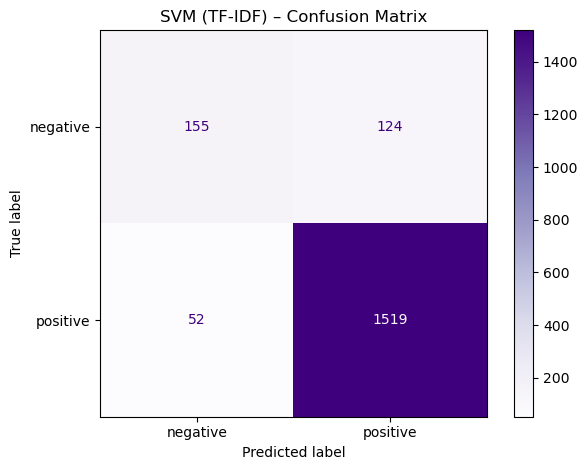

In [28]:
cm_svm = confusion_matrix(y_test, svm_tfidf_pred)
ConfusionMatrixDisplay(cm_svm, display_labels=label_names).plot(cmap='Purples')
plt.title('SVM (TF-IDF) – Confusion Matrix')
plt.tight_layout()
plt.show()

In [29]:
results = pd.DataFrame({
    'Model': ['TextBlob', 'VADER', 'NB + BoW', 'NB + TF-IDF', 'SVM + BoW', 'SVM + TF-IDF'],
    'Accuracy': [tb_acc, vd_acc, nb_bow_acc, nb_tfidf_acc, svm_bow_acc, svm_tfidf_acc]
})
results['Accuracy'] = results['Accuracy'].round(4)
print(results.to_string(index=False))

       Model  Accuracy
    TextBlob    0.8687
       VADER    0.8893
    NB + BoW    0.9054
 NB + TF-IDF    0.8524
   SVM + BoW    0.8778
SVM + TF-IDF    0.9049


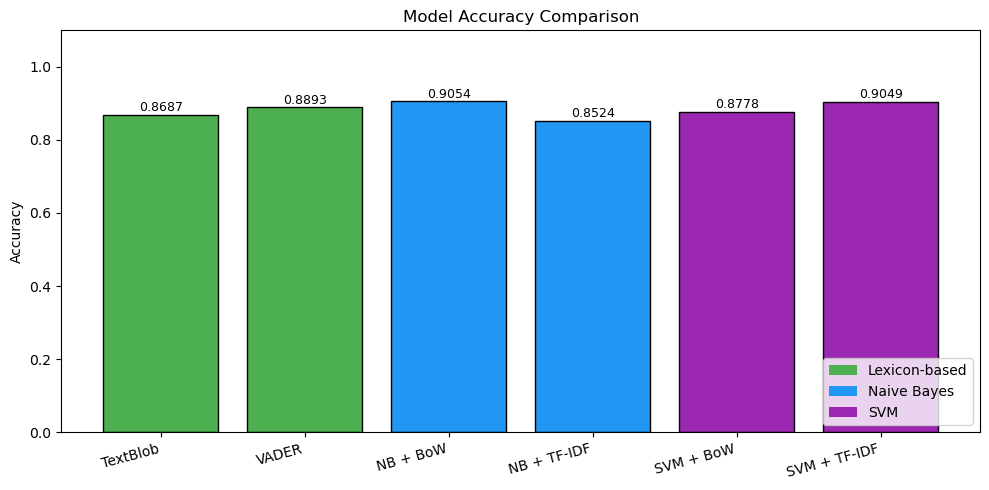

Best model: NB + BoW — Accuracy: 0.9054


In [30]:
from matplotlib.patches import Patch

colors = ['#4CAF50','#4CAF50','#2196F3','#2196F3','#9C27B0','#9C27B0']

plt.figure(figsize=(10, 5))
bars = plt.bar(results['Model'], results['Accuracy'], color=colors, edgecolor='black')
plt.ylim(0, 1.1)
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.xticks(rotation=15, ha='right')

for bar, acc in zip(bars, results['Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.4f}', ha='center', fontsize=9)

legend_elements = [
    Patch(facecolor='#4CAF50', label='Lexicon-based'),
    Patch(facecolor='#2196F3', label='Naive Bayes'),
    Patch(facecolor='#9C27B0', label='SVM')
]
plt.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()

best = results.loc[results['Accuracy'].idxmax()]
print(f"Best model: {best['Model']} — Accuracy: {best['Accuracy']:.4f}")

In [31]:
# CISB5123 Text Analytics — Lab Assignment 2
## Sentiment Analysis on Amazon Fine Food Reviews

**Name:** Muhammad Salman
**Student ID:** IS01083889

---

### Discussion: Strengths and Weaknesses of Selected Models

In this assignment, four sentiment classification models were evaluated: TextBlob, VADER, Naive Bayes, and Support Vector Machine (SVM). TextBlob is a lexicon-based approach that is simple to use and requires no training data, making it easy to deploy; however, it relies on a fixed dictionary and struggles with sarcasm, domain-specific language, and context-dependent phrases commonly found in food reviews. VADER is also lexicon-based and performs better than TextBlob on short, informal text as it accounts for punctuation and capitalization, but it is less effective on longer structured reviews where deeper contextual understanding is needed. Naive Bayes is a machine learning model that is computationally efficient and provides a strong baseline for binary classification; its main weakness is the independence assumption between features, which does not always hold true in natural language. SVM generally achieves the highest accuracy among the four models due to its ability to find optimal decision boundaries in high-dimensional feature spaces, but it is more computationally expensive and sensitive to hyperparameter settings compared to the other approaches.

SyntaxError: invalid syntax (1376198083.py, line 4)

In [32]:
# ============================================================
# CISB5123 Text Analytics — Lab Assignment 2
# Sentiment Analysis on Amazon Fine Food Reviews
#
# Name       : Muhammad Salman
# Student ID : IS01083889
#
# Discussion: Strengths and Weaknesses of Selected Models
#
# In this assignment, four sentiment classification models
# were evaluated: TextBlob, VADER, Naive Bayes, and SVM.
# TextBlob is simple and requires no training data, but relies
# on a fixed dictionary and struggles with sarcasm and
# domain-specific language. VADER handles short informal text
# better by accounting for punctuation and capitalization, but
# is less effective on longer structured reviews. Naive Bayes
# is computationally efficient and a good baseline, but its
# feature independence assumption does not always ho



In [35]:
# ============================================================
# CISB5123 Text Analytics — Lab Assignment 2
# Sentiment Analysis on Amazon Fine Food Reviews
#
# Name       : Muhammad Salman
# Student ID : IS01083889
#
# Discussion: Strengths and Weaknesses of Selected Models
#
# In this assignment, four sentiment classification models
# were evaluated: TextBlob, VADER, Naive Bayes, and SVM.
# TextBlob is simple and requires no training data, but relies
# on a fixed dictionary and struggles with sarcasm and
# domain-specific language. VADER handles short informal text
# better by accounting for punctuation and capitalization, but
# is less effective on longer structured reviews. Naive Bayes
# is computationally efficient and a good baseline, but its
# feature independence assumption does not always hold in
# natural language. SVM generally achieves the highest accuracy
# due to its ability to find optimal decision boundaries in
# high-dimensional spaces, but is more computationally expensive
# and sensitive to hyperparameter settings.
# ============================================================